In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [13]:
result_dict["feat_imp"].tail(20).index.tolist()

['T2_FGA3_diff',
 'T2_possessions_diff',
 'T1_OR',
 'delta_FGM2',
 'T1_FGM',
 'T1_FGM_diff',
 'T1_N_wins',
 'delta_DR_opportunity',
 'T1_Eff_shooting_perc',
 'delta_opp_FTA',
 'T2_TO_diff',
 'T1_Eff_FG_perc_diff',
 'delta_PF_diff',
 'T1_OR_opportunity',
 'T2_Opp_eff_shooting_perc',
 'delta_FGM2_perc',
 'T2_DR',
 'T1_DR_opportunity_diff',
 'T1_Stl',
 'delta_Score']

OOF score: 0.18855573120782013
[24, 293, 49, 74, 45]


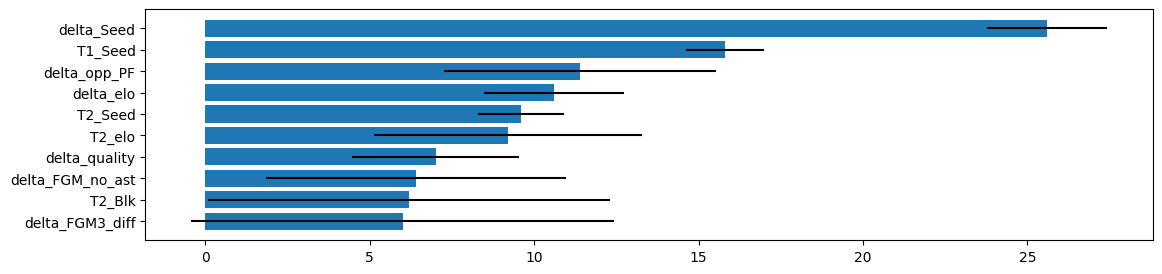

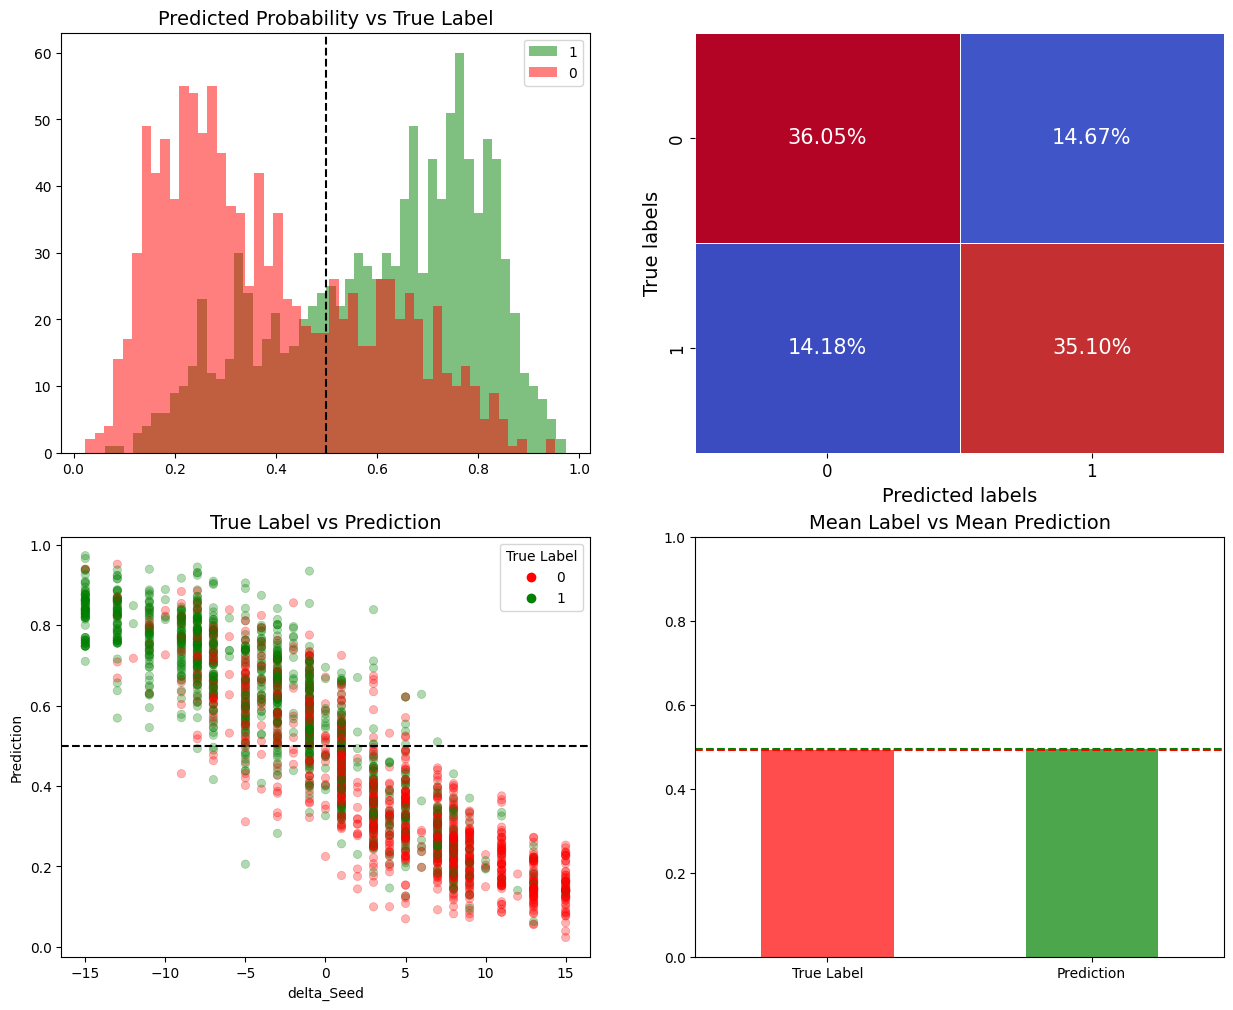

Accuracy score: 	0.7115
AUC ROC: 		0.7876
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1127
           1       0.71      0.71      0.71      1095

    accuracy                           0.71      2222
   macro avg       0.71      0.71      0.71      2222
weighted avg       0.71      0.71      0.71      2222

Test score: 0.1878137029178038


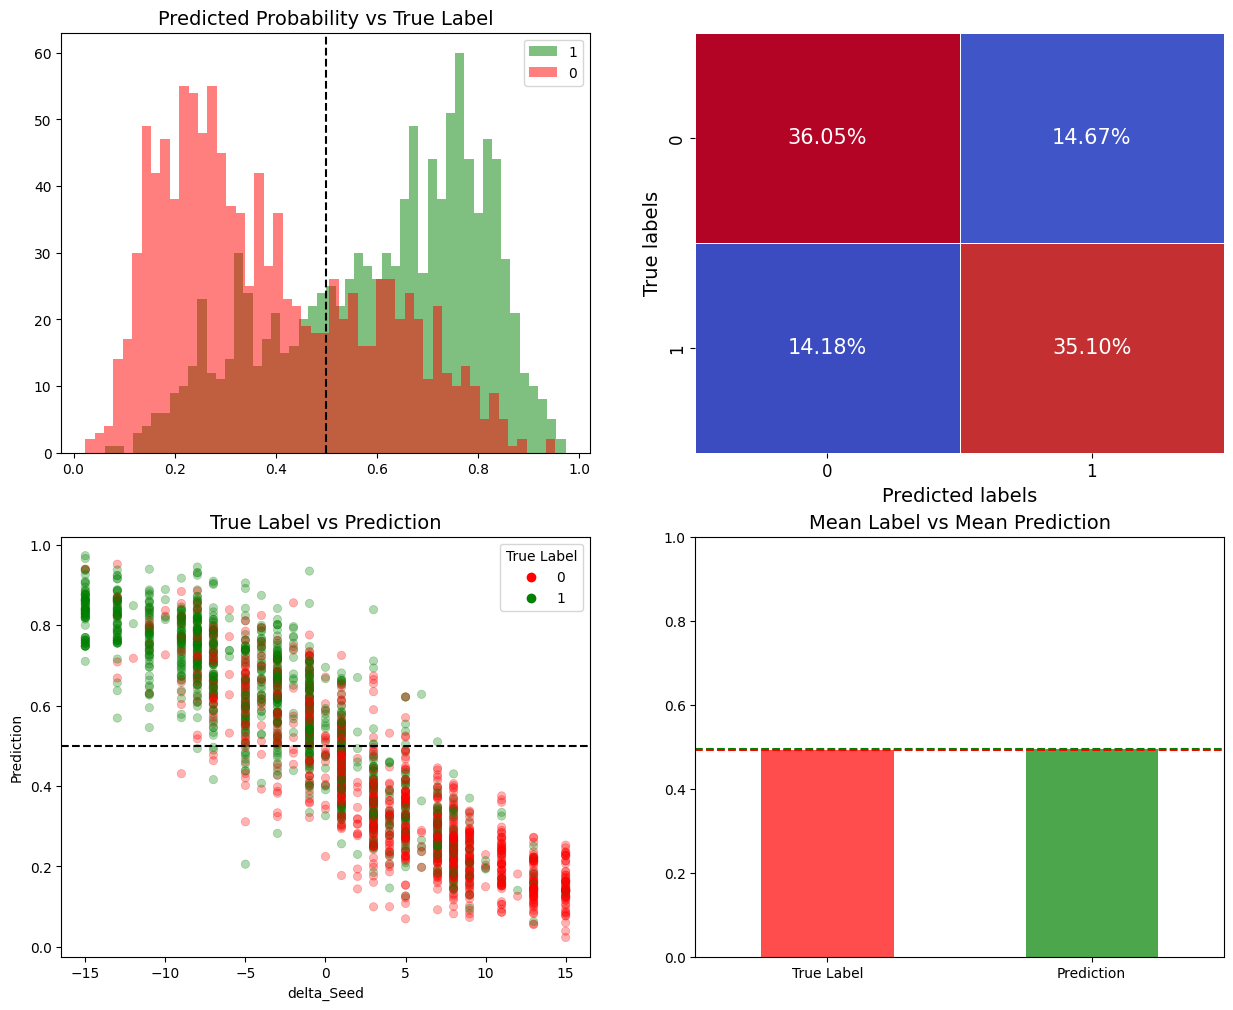

Accuracy score: 	0.7115
AUC ROC: 		0.7876
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1127
           1       0.71      0.71      0.71      1095

    accuracy                           0.71      2222
   macro avg       0.71      0.71      0.71      2222
weighted avg       0.71      0.71      0.71      2222

Accuracy train: 		 0.7115
Accuracy test: 			 0.696
Logloss train: 			 0.5586
Logloss test: 			 0.5559
Brier train: 			 0.1886
Brier test: 			 0.1878
Unsure train: 			 21.6922%
Unsure test: 			 19.4245%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7115,0.696,0.5586,0.5559,21.6922,19.4245,0.1886,0.1878


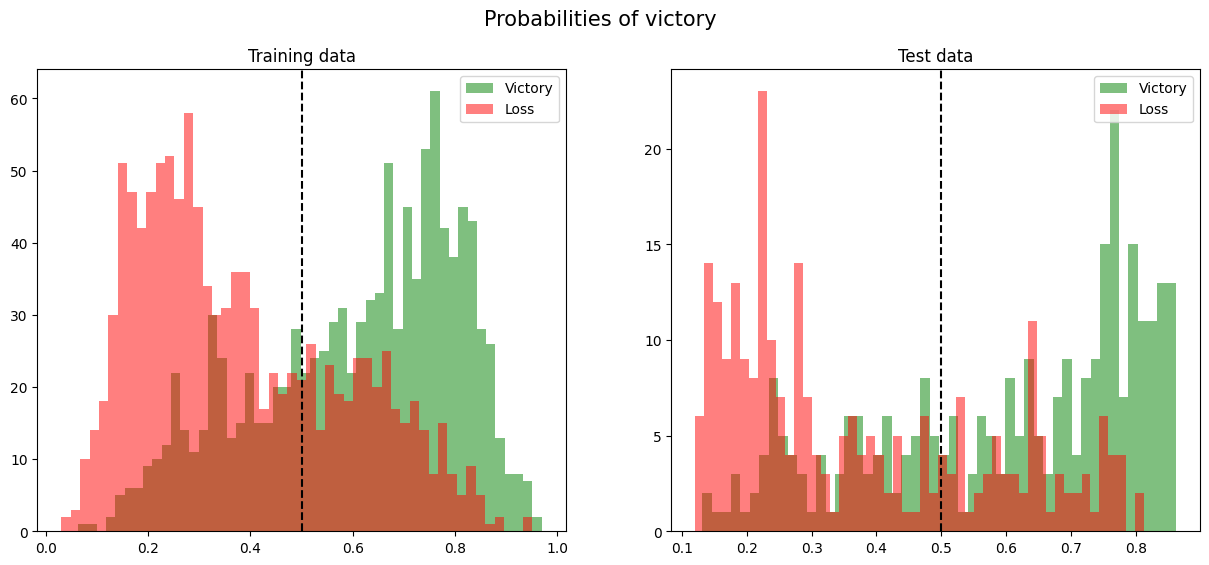

In [22]:
target = df_train["target"]

not_imp = [
    'T1_Opp_True_shooting_perc',
 'T1_Opp_eff_shooting_perc',
 'T2_FTA_diff',
 'T2_FTM',
 'T2_N_wins',
 'T2_Opp_True_shooting_perc',
 'T1_FGM_perc',
 'T2_Blk_diff',
 'T2_FGA2',
 'T2_FGM2_perc',
 'T2_FGM_diff',
 'T1_FGM3',
 'T2_FG3_ratio',
 'T2_Ast',
 'T2_Ast_TO_ratio_diff',
 'delta_OT_win_perc',
 'delta_True_shooting_perc_diff',
 'delta_def_edge',
 'T1_DR_opportunity',
 'T2_Eff_shooting_perc',
 
 'delta_TO_diff',
 'delta_TO_perposs',
 'T1_FGA3',
 'T1_FGA3_diff',
 'T1_FGA_diff',
 'T2_FGM3_perc',
 'T1_opp_score',
 'T2_opp_FGA',
 'T1_Tot_Reb',
 'T1_opp_shtg_opportunity',
 'T1_possessions',
 'T1_TO_diff',
 'delta_DR',
 'delta_FGA2',
 'delta_FGA2_diff',
 'T2_Score',
 'T2_Score_diff',
 'T2_Stl',
 'T2_TO_perposs_diff',
 'T2_def_rating',
 'T2_impact_diff',
 'delta_FGA3',
 'delta_FTM_diff',
 'T2_FGM',
 'T1_Ast_TO_ratio_diff',
 'T1_Ast_diff',
 'T1_DR',
 'delta_Tot_Reb',
 'delta_Tot_Reb_diff',
 'T1_opp_FGA',
 'T2_FGM2_diff',
 'T2_FGM3_diff',
 'delta_OR_opportunity_diff',
 'delta_FGM2_diff',
 'delta_FTM',
 'delta_possessions',
 'delta_def_rating',
 'T1_Ast',
 'stage_Round1',
 'delta_opp_FGA',
 'delta_opp_FGM',
 'delta_opp_TO',
 'delta_opp_possessions',
 'T1_FGM2_perc',
 'T1_FGM3_diff',
 'delta_FGM3',
 'T1_FTA',
 'T1_FGM3_perc',
 'delta_FG3_ratio',
 'delta_FG3_ratio_diff',
 'delta_FGA',
 'delta_DR_diff',
 'delta_DR_opportunity_diff',
 'T1_OT_win_perc',
 'T2_opp_FGM3',
 'delta_Opp_eff_shooting_perc',
 'T1_FGA2',
 'T2_opp_FGM',
 'T1_Tot_Reb_diff',
 'T2_TO_perposs',
 'T2_impact',
 'T1_opp_FGM3',
 'delta_TO_perposs_diff',
 'T2_OR',
 'T2_OR_opportunity',
 'T2_OR_opportunity_diff',
 'T2_OT_win',
 'T2_OT_win_perc',
 'T2_FTM_diff',
 'T1_opp_TO',
 'T2_FGM_no_ast_diff',
 'T2_FGM_perc',
 'delta_impact',
 'delta_off_edge',
 'stage_Round2',
 'stage_Round3',
 'stage_Round4',
 'stage_final',
 'stage_finalfour',
 'stage_impossible']

extras = ["T1_Opp_True_shooting_perc", "T2_Opp_True_shooting_perc",
          #"T1_Seed", "T2_Seed",
          #"T1_impact", "T2_impact", "T1_FGM3_perc", "T2_FGM3_perc"
          ]
FEATURES = [c for c in df_train if c not in DROP and c not in not_imp] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

model = lgb.LGBMClassifier(random_state=34, n_jobs=-1, verbose=-1, n_estimators=10000,
                               learning_rate=0.1,
                             colsample_bytree=0.41,
                             min_child_weight=47.85,
                             reg_lambda=44,
                             reg_alpha=3.5,
                             subsample=0.9,
                             num_leaves=51,
                             max_depth=92,
                             eval_metric="auc")

pipe = Pipeline([
                ("imp", tml.DfImputer()),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "auc"}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=False, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

In [25]:
df_train["oof_prob"] = oof
df_test["pred_prob"] = pred

df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [26]:
df_train.groupby("stage_Round1")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round1,
False,0.204014
True,0.173509


In [27]:
df_train.groupby("stage_Round2")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round2,
False,0.190361
True,0.183237


In [28]:
df_train.groupby("stage_Round3")[[ "sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round3,
False,0.184293
True,0.218118


In [29]:
df_train.groupby("stage_Round4")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round4,
False,0.183924
True,0.257959


In [30]:
df_train.groupby("stage_finalfour")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_finalfour,
False,0.187573
True,0.217092


In [31]:
df_train.groupby("stage_final")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_final,
False,0.188573
True,0.187471


In [32]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18855573120782013
1 0.18855546218282734
2 0.18855511587595866
3 0.18854683741394798
4 0.18854326475919975
5 0.18854318109008844
6 0.18854472172201672
7 0.1885583758814936
8 0.18856972992239843
9 0.18857969633999766
10 0.18859217652863292
11 0.18861264173457698
12 0.1886550072282353
13 0.18872546701048554
14 0.1888098015289669
15 0.1889061092009184
16 0.18902618777808125
17 0.18915948704913618
18 0.18931344486341317
19 0.18947606757847105
20 0.18964607916487072
21 0.1898333901616176
22 0.1900340726320296
23 0.1902522888234961
24 0.1904877208657307


Round 2 12
 

In [33]:
df_train.to_csv("data/results/men_train_lgb_class.csv", index=False)
df_test.to_csv("data/results/men_test_lgb_class.csv", index=False)